# E-commerce Sales Analysis

## 1. Data Loading and Initial Audit

The dataset is loaded and examined to understand its structure, data types, completeness, and general characteristics.

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/Sample - Superstore.csv", encoding="latin1")

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 9994
Columns: 21


In [6]:
df.shape

(9994, 21)

In [7]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [9]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.nunique()

Row ID           9994
Order ID         5009
Order Date       1237
Ship Date        1334
Ship Mode           4
Customer ID       793
Customer Name     793
Segment             3
Country             1
City              531
State              49
Postal Code       631
Region              4
Product ID       1862
Category            3
Sub-Category       17
Product Name     1850
Sales            5825
Quantity           14
Discount           12
Profit           7287
dtype: int64

In [12]:
df["Discount"].unique()

array([0.  , 0.45, 0.2 , 0.8 , 0.3 , 0.5 , 0.7 , 0.6 , 0.32, 0.1 , 0.4 ,
       0.15])

In [13]:
df["Category"].unique()

<StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str

## 2. Data Preparation

Date columns are converted to datetime format to enable temporal analysis. Additional features are created to support the analysis.

In [14]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [15]:
df["Order Month"] = df["Order Date"].dt.to_period("M")

In [16]:
df["Order Year"] = df["Order Date"].dt.year

In [17]:
duplicate_rows = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_rows}")

Duplicate rows: 0


In [18]:
df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

In [19]:
df[["Order Date", "Ship Date"]].isna().sum()

Order Date    0
Ship Date     0
dtype: int64

In [20]:
df[["Sales", "Quantity", "Discount", "Profit"]].min()

Sales          0.444
Quantity       1.000
Discount       0.000
Profit     -6599.978
dtype: float64

In [21]:
df[["Sales", "Quantity", "Discount", "Profit"]].max()

Sales       22638.480
Quantity       14.000
Discount        0.800
Profit       8399.976
dtype: float64

In [22]:
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [23]:
import pandas as pd

df = pd.read_csv("../data/Sample - Superstore.csv", encoding="latin1")

## 3. Sales and Profit Analysis

This section evaluates the overall sales performance, total profit, and profit margin of the dataset.

In [24]:
df[["Sales", "Profit"]].sum()

Sales     2.297201e+06
Profit    2.863970e+05
dtype: float64

In [25]:
df["Profit"].sum() / df["Sales"].sum()

np.float64(0.12467217240315605)

In [26]:
df.groupby("Category")[["Sales", "Profit"]].sum()

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


## 4. Category Analysis

Sales and profit are compared across product categories to identify differences in financial performance.

In [27]:
df.groupby("Category")[["Sales", "Profit"]].sum().assign(
    Margin=lambda x: x["Profit"] / x["Sales"]
)

,Sales,Profit,Margin
Category,,,
Furniture,741999.7953,18451.2728,0.024867
Office Supplies,719047.0320,122490.8008,0.170352
Technology,836154.0330,145454.9481,0.173957


<Axes: xlabel='Category'>

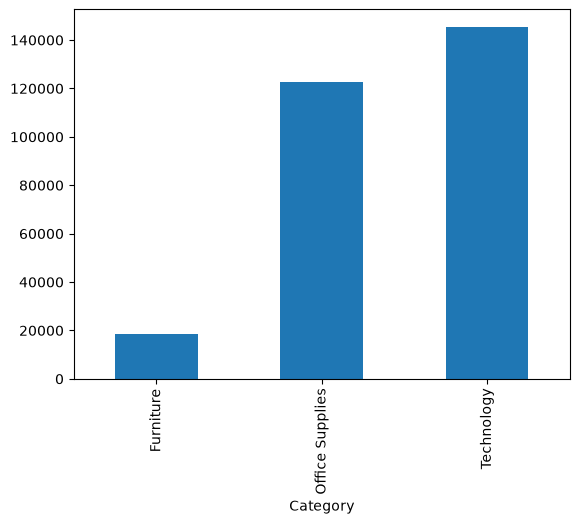

In [28]:
category_profit = df.groupby("Category")["Profit"].sum()

category_profit.plot(kind="bar")

<Axes: xlabel='Category'>

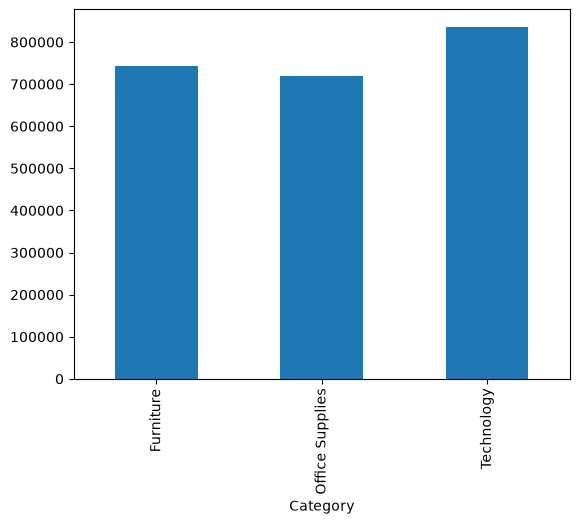

In [29]:
category_sales = df.groupby("Category")["Sales"].sum()

category_sales.plot(kind="bar")

## 5. Discount Analysis

The relationship between discount levels and profitability is examined to identify patterns associated with lower financial performance.

In [30]:
df.groupby("Discount")["Profit"].mean()

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64

<Axes: xlabel='Discount'>

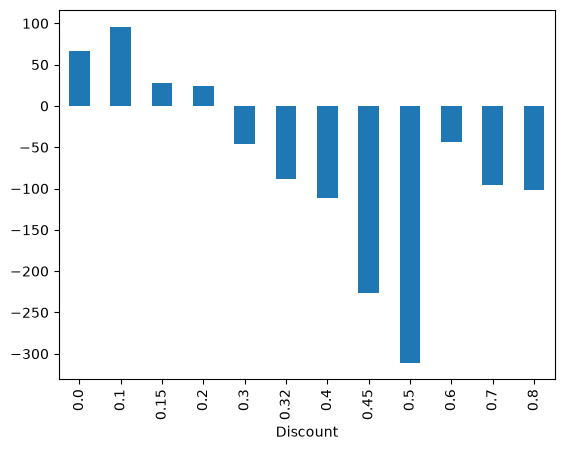

In [31]:
discount_profit = df.groupby("Discount")["Profit"].mean()

discount_profit.plot(kind="bar")

In [32]:
df["Discount"].value_counts().sort_index()

Discount
0.00    4798
0.10      94
0.15      52
0.20    3657
0.30     227
0.32      27
0.40     206
0.45      11
0.50      66
0.60     138
0.70     418
0.80     300
Name: count, dtype: int64

In [33]:
df.groupby("Discount")["Sales"].sum().sort_index()

Discount
0.00    1.087908e+06
0.10    5.436935e+04
0.15    2.755852e+04
0.20    7.645944e+05
0.30    1.032267e+05
0.32    1.449346e+04
0.40    1.164178e+05
0.45    5.484974e+03
0.50    5.891854e+04
0.60    6.644700e+03
0.70    4.062028e+04
0.80    1.696376e+04
Name: Sales, dtype: float64

In [34]:
df.groupby("Discount")["Profit"].sum().sort_index()

Discount
0.00    320987.6032
0.10      9029.1770
0.15      1418.9915
0.20     90337.3060
0.30    -10369.2774
0.32     -2391.1377
0.40    -23057.0504
0.45     -2493.1111
0.50    -20506.4281
0.60     -5944.6552
0.70    -40075.3569
0.80    -30539.0392
Name: Profit, dtype: float64

In [35]:
df["Order Date"].min(), df["Order Date"].max()

('1/1/2017', '9/9/2017')

In [36]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [37]:
df[["Order Date", "Order Month"]].head()

KeyError: "['Order Month'] not in index"

## 6. Temporal Analysis

Sales performance is analyzed over time to identify trends and changes in annual and monthly revenue.

In [ ]:
df.groupby("Order Month")["Sales"].sum()

In [ ]:
monthly_sales = df.groupby("Order Month")["Sales"].sum()

monthly_sales.plot(
    kind="line",
    title="Vendas mensais"
)

In [ ]:
df.groupby(df["Order Date"].dt.year)["Sales"].sum()

In [ ]:
df.groupby(df["Order Date"].dt.year)["Profit"].sum()

## 7. Regional Analysis

Sales, profit, and profit margin are compared across regions to identify differences in regional performance.

In [ ]:
df.groupby("Region")[["Sales", "Profit"]].sum()

In [ ]:
region_analysis = df.groupby("Region")[["Sales", "Profit"]].sum()

region_analysis["Margin"] = region_analysis["Profit"] / region_analysis["Sales"]

region_analysis

In [ ]:
subcategory_analysis = df.groupby("Sub-Category")[["Sales", "Profit"]].sum()

subcategory_analysis.sort_values("Profit", ascending=False)

In [ ]:
subcategory_analysis["Margin"] = (
    subcategory_analysis["Profit"] / subcategory_analysis["Sales"]
)

subcategory_analysis.sort_values("Margin", ascending=False)

## 8. Sub-Category Analysis

Product sub-categories are compared by sales, profit, profit margin, and average discount to identify the most and least profitable areas.

In [ ]:
df.groupby("Sub-Category")["Discount"].mean().sort_values(ascending=False)

## 9. Key Findings

- Total sales were approximately $2.30M, with total profit of approximately $286K.
- The overall profit margin was approximately 12.47%.
- Technology generated the highest total sales and profit among the three categories.
- Furniture had substantially lower profitability than Office Supplies and Technology.
- Higher discount levels were associated with lower profitability, with observed levels from 30% onward generating negative total profit.
- Sales increased by approximately 51.4% between 2014 and 2017.
- The West region had the highest sales, profit, and profit margin.
- Tables generated more than $206K in sales but resulted in a negative profit of approximately $17.7K.
- Labels had the highest profit margin at approximately 44.4%.